In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.config import *
from src.utils import *
import datetime

In [2]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-05-23 12:37:29.341086


In [3]:
#load latest final dataset cleaned

final_dataset_file = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)

dataset = pd.read_csv(final_dataset_file)
print("Loaded dataset: ", final_dataset_file)


Loaded dataset:  data/final_cleaned_dataset/nba_features_cleaned_final_2025-05-23_11-59-28.csv


## # 1. Vue d'ensemble rapide


In [4]:

print("\nShape:", dataset.shape)
print("\nColumns:", dataset.columns.tolist())
print("\nSample:\n", dataset.head(3))
print("\nWin distribution:\n", dataset['IS_WIN'].value_counts(normalize=True))
print("\nNombre de valeurs NaN par colonne:\n", dataset.isnull().sum().sort_values(ascending=False).head(10))



Shape: (64136, 159)

Columns: ['TEAM_ID', 'IS_WIN', 'IS_HOME', 'ROLL_HOME_WINRATE_5', 'ROLL_AWAY_WINRATE_5', 'ROLL_HOME_WINRATE_10', 'ROLL_AWAY_WINRATE_10', 'ROLL_HOME_WINRATE_25', 'ROLL_AWAY_WINRATE_25', 'ROLL_HOME_WINRATE_50', 'ROLL_AWAY_WINRATE_50', 'ROLL_HOME_WINRATE_100', 'ROLL_AWAY_WINRATE_100', 'ROLL_HOME_WINRATE_200', 'ROLL_AWAY_WINRATE_200', 'HOME_WIN_STREAK', 'AWAY_WIN_STREAK', 'ROLL_HOME_PTS_FOR_5', 'ROLL_HOME_PTS_AGAINST_5', 'ROLL_AWAY_PTS_FOR_5', 'ROLL_AWAY_PTS_AGAINST_5', 'ROLL_HOME_PTS_FOR_10', 'ROLL_HOME_PTS_AGAINST_10', 'ROLL_AWAY_PTS_FOR_10', 'ROLL_AWAY_PTS_AGAINST_10', 'ROLL_HOME_PTS_FOR_25', 'ROLL_HOME_PTS_AGAINST_25', 'ROLL_AWAY_PTS_FOR_25', 'ROLL_AWAY_PTS_AGAINST_25', 'ROLL_HOME_PTS_FOR_50', 'ROLL_HOME_PTS_AGAINST_50', 'ROLL_AWAY_PTS_FOR_50', 'ROLL_AWAY_PTS_AGAINST_50', 'ROLL_HOME_PTS_FOR_100', 'ROLL_HOME_PTS_AGAINST_100', 'ROLL_AWAY_PTS_FOR_100', 'ROLL_AWAY_PTS_AGAINST_100', 'ROLL_HOME_PTS_FOR_200', 'ROLL_HOME_PTS_AGAINST_200', 'ROLL_AWAY_PTS_FOR_200', 'ROLL_AWA

## 2. Heatmap de corrélation (on filtre un peu pour pas exploser la RAM)

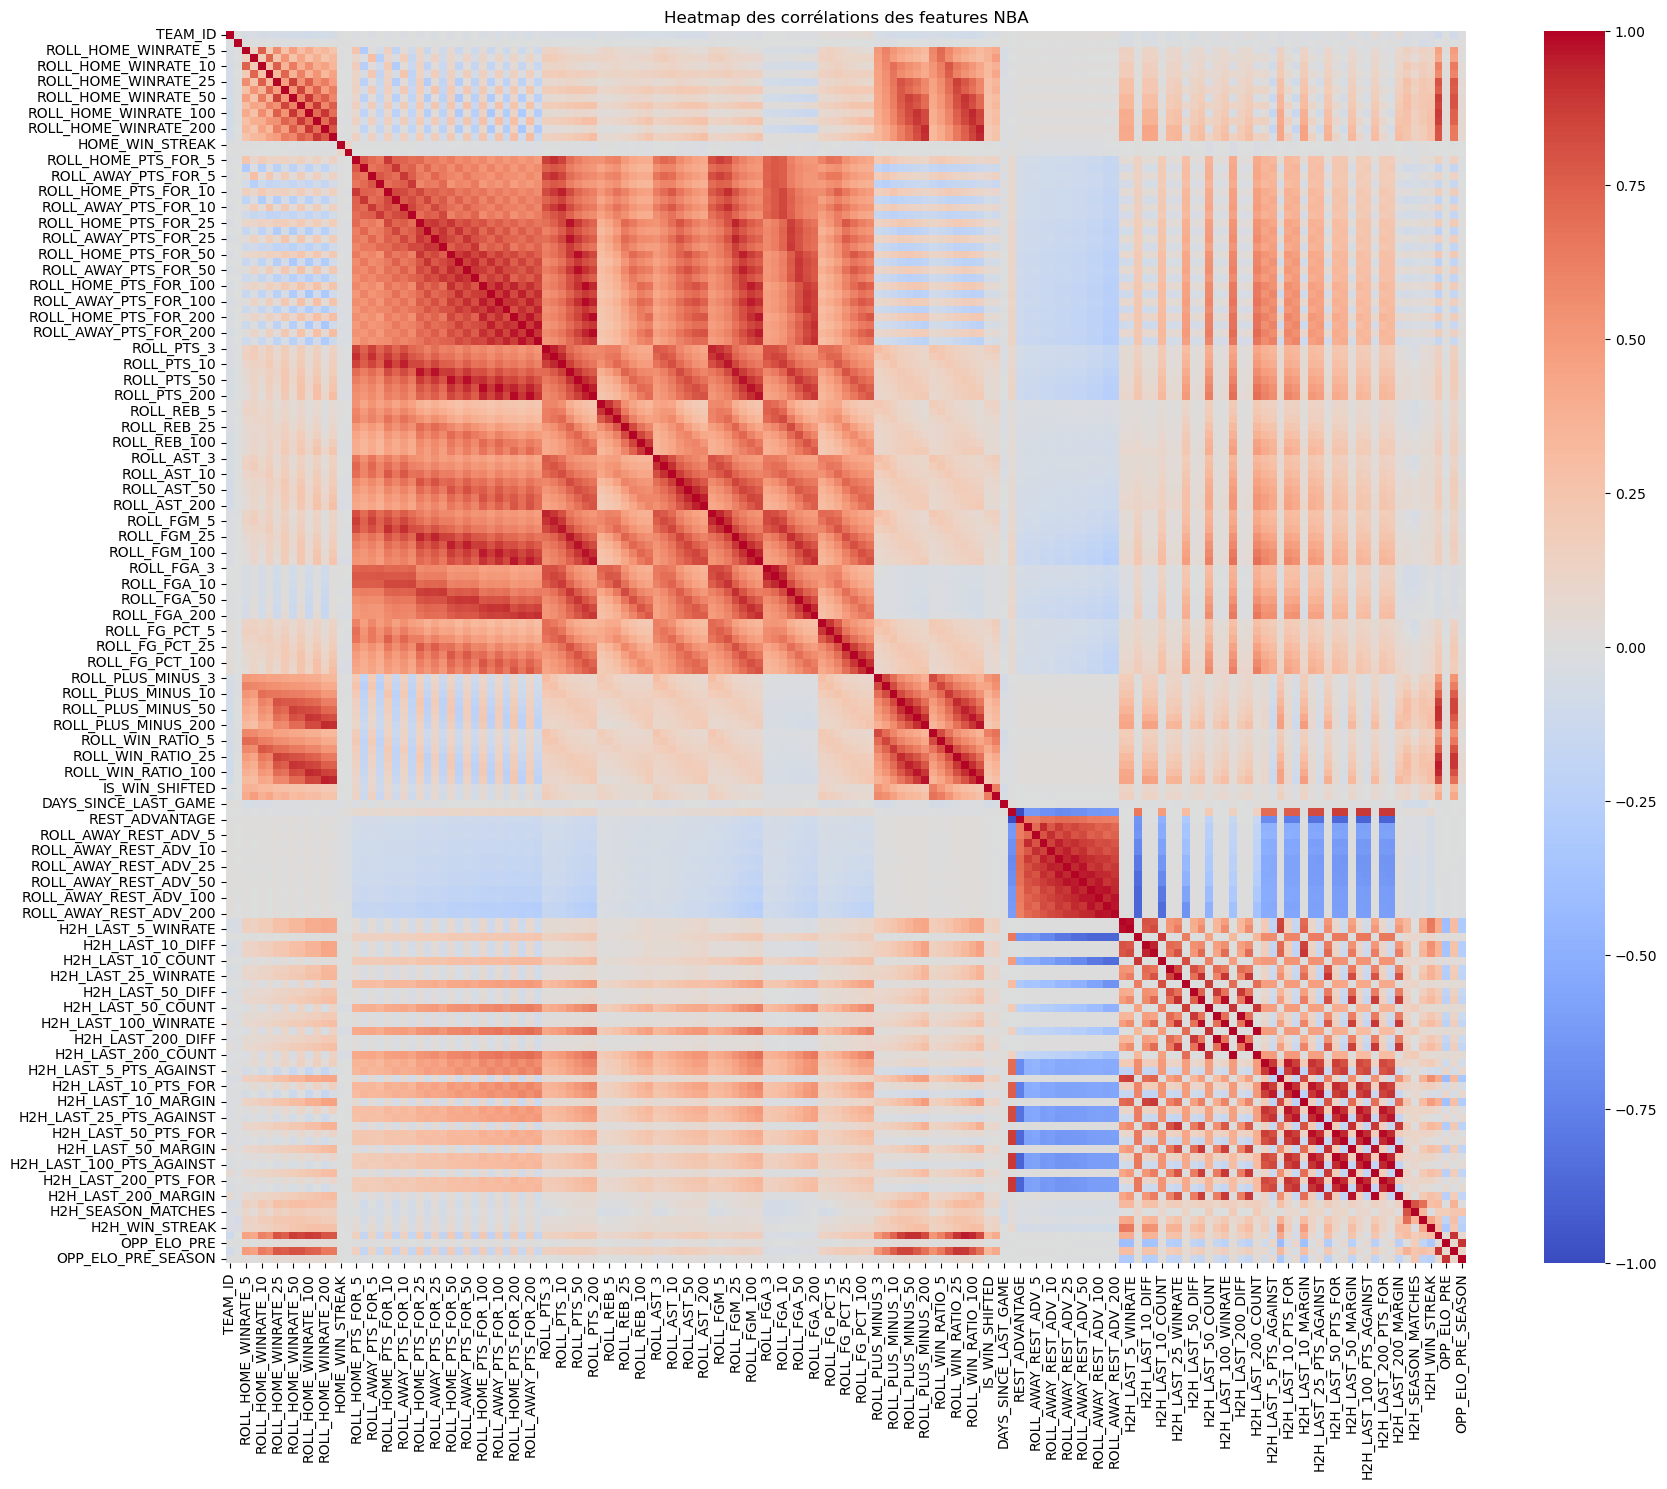

In [5]:
num_cols = [c for c in dataset.columns if dataset[c].dtype in [np.float64, np.int64, np.float32, np.int32]]
num_cols = [c for c in num_cols if c != 'IS_WIN']  # on exclut la target
corr = dataset[num_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title("Heatmap des corrélations des features NBA")
plt.show()

## 3. Distribution de features par win/lose

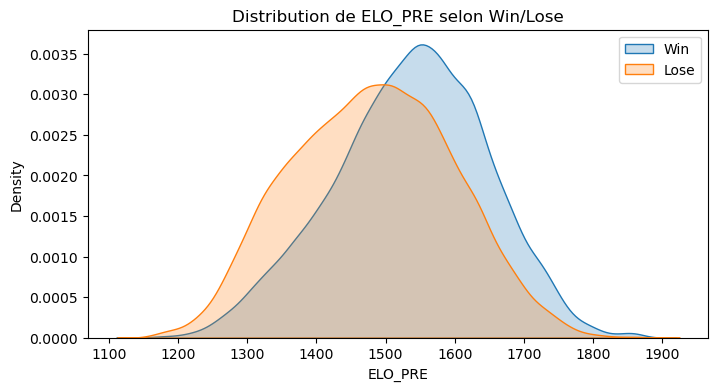

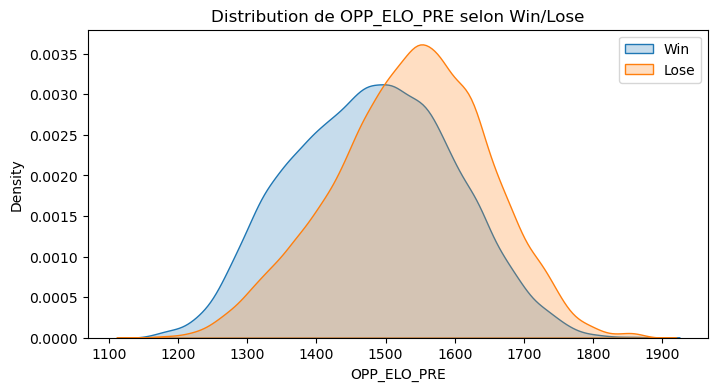

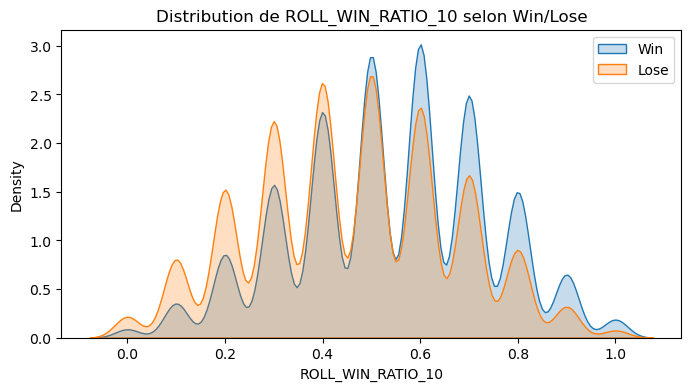

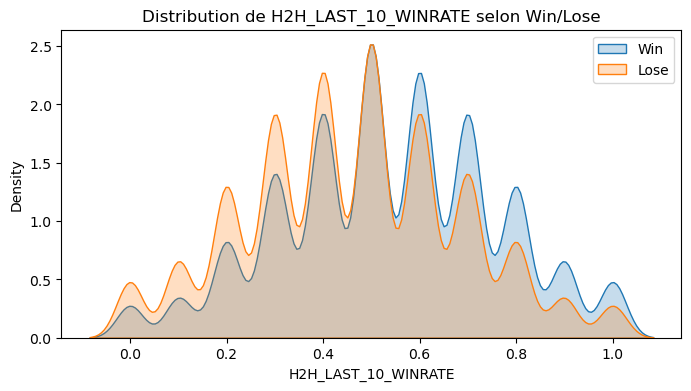

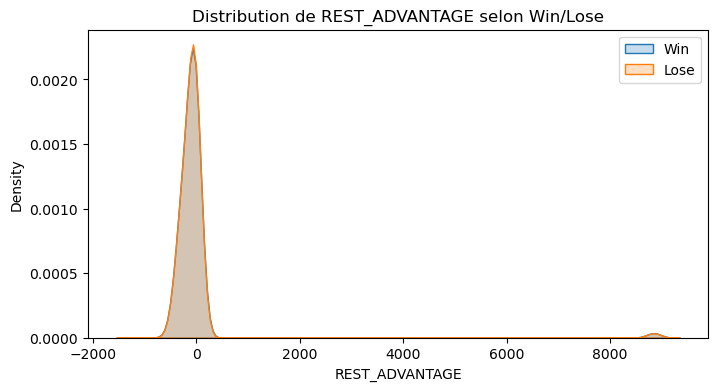

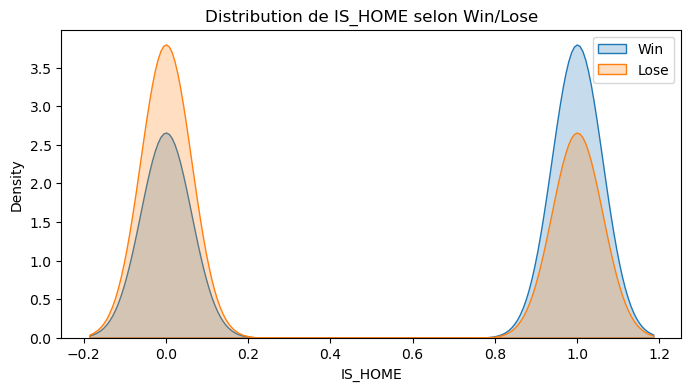

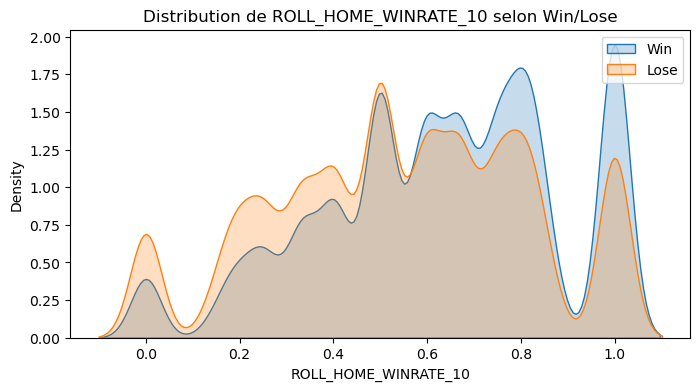

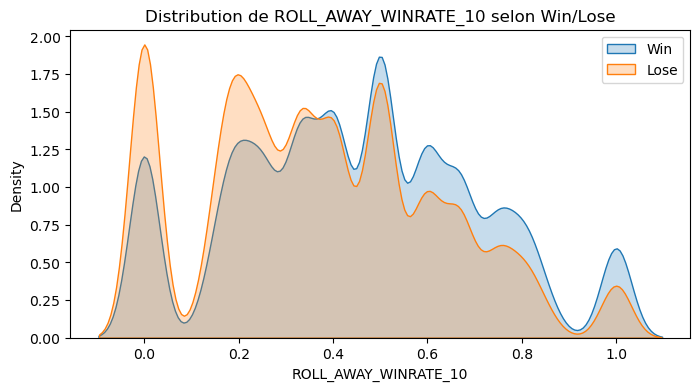

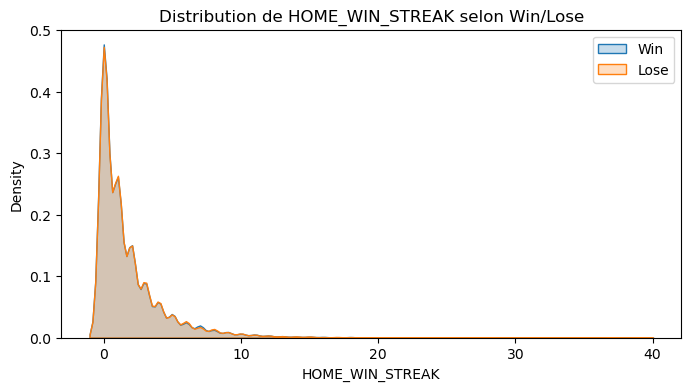

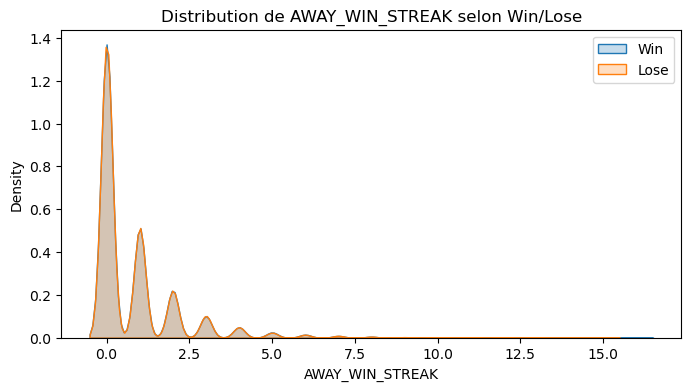

In [6]:
features_to_plot = [
    'ELO_PRE', 'OPP_ELO_PRE',
    'ROLL_WIN_RATIO_10', 'H2H_LAST_10_WINRATE', 'REST_ADVANTAGE', 'IS_HOME',
    'ROLL_HOME_WINRATE_10', 'ROLL_AWAY_WINRATE_10', 'HOME_WIN_STREAK', 'AWAY_WIN_STREAK'
]
for feat in features_to_plot:
    if feat in dataset.columns:
        plt.figure(figsize=(8,4))
        sns.kdeplot(dataset[feat][dataset['IS_WIN'] == 1].dropna(), label='Win', fill=True)
        sns.kdeplot(dataset[feat][dataset['IS_WIN'] == 0].dropna(), label='Lose', fill=True)
        plt.title(f'Distribution de {feat} selon Win/Lose')
        plt.legend()
        plt.show()

## Split train/test

In [7]:
from sklearn.model_selection import train_test_split

# On prend toutes les colonnes numériques sauf la target
target = 'IS_WIN'
drop_cols = ['TEAM_ID','SEASON']  # À adapter selon ce que tu veux/veux pas inclure
features = [col for col in dataset.columns if col not in [target] + drop_cols]

#drop na cols
dataset = dataset.dropna(subset=features)

X = dataset[features]
y = dataset[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)
print(X_train.shape, X_test.shape)


(48857, 156) (12215, 156)


## Premier modèle : Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score





clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.64      0.66      0.65      6051
           1       0.65      0.63      0.64      6164

    accuracy                           0.64     12215
   macro avg       0.64      0.64      0.64     12215
weighted avg       0.64      0.64      0.64     12215

ROC AUC: 0.6991895006440497


###  Importance des features


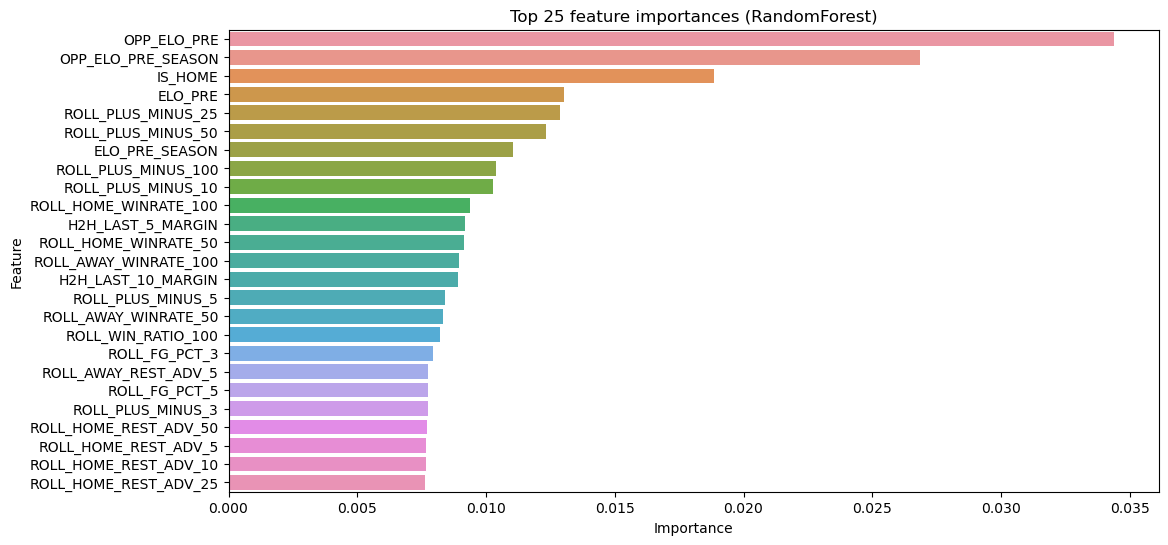

In [9]:
importances = clf.feature_importances_
feature_names = X_train.columns
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (RandomForest)")
plt.show()


## Alternative : LightGBM

In [10]:
%pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Note: you may need to restart the kernel to use updated packages.


[LightGBM] [Info] Number of positive: 24382, number of negative: 24475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31492
[LightGBM] [Info] Number of data points in the train set: 48857, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499048 -> initscore=-0.003807
[LightGBM] [Info] Start training from score -0.003807
              precision    recall  f1-score   support

           0       0.65      0.67      0.66      6051
           1       0.67      0.65      0.66      6164

    accuracy                           0.66     12215
   macro avg       0.66      0.66      0.66     12215
weighted avg       0.66      0.66      0.66     12215

ROC AUC: 0.7206994119098629


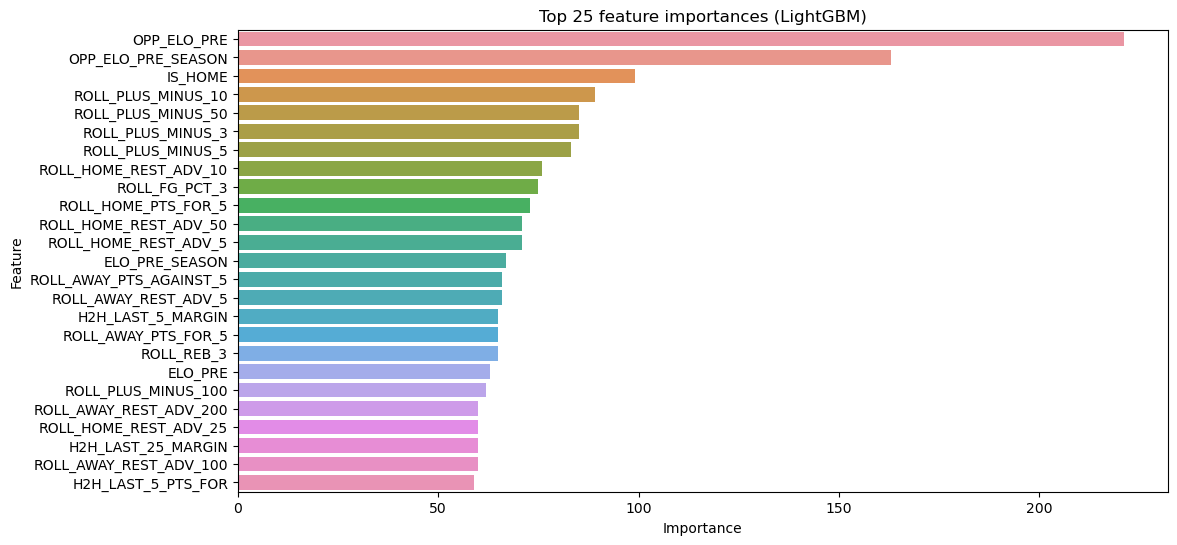

In [11]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

# Feature importance
importances = lgbm.feature_importances_
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (LightGBM)")
plt.show()


## Alternative XGBoost 

In [12]:
%pip install xgboost

  Using cached xgboost-3.0.1-py3-none-manylinux_2_28_x86_64.whl (253.9 MB)
  Using cached nvidia_nccl_cu12-2.26.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (318.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)
probas = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probas))


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:38:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.66      0.67      0.66      6051
           1       0.67      0.66      0.66      6164

    accuracy                           0.66     12215
   macro avg       0.66      0.66      0.66     12215
weighted avg       0.66      0.66      0.66     12215

ROC AUC: 0.7241519493991746


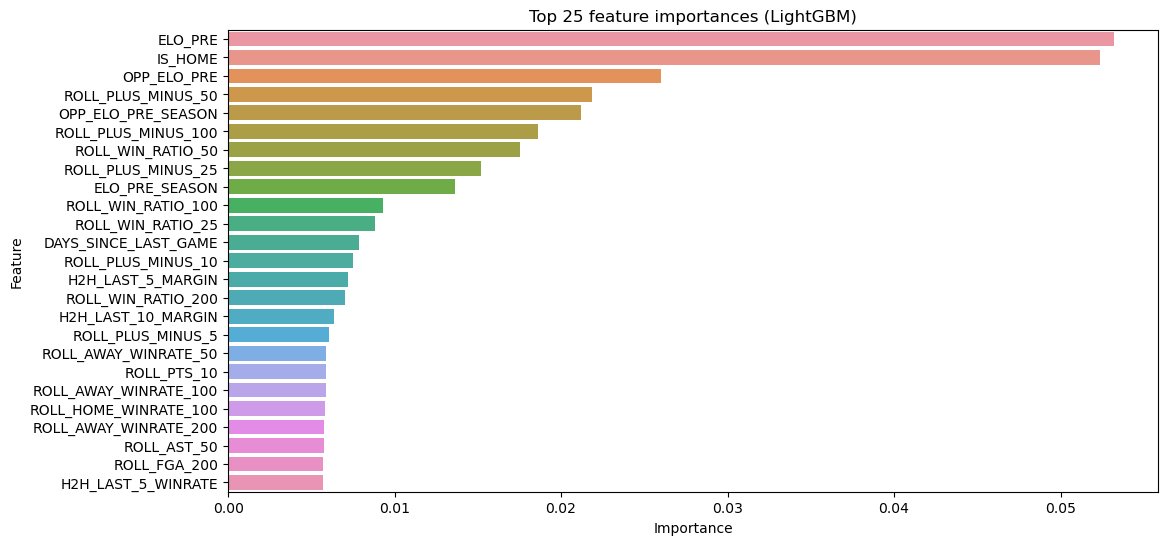

In [14]:
# Feature importance
importances = xgb.feature_importances_
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (LightGBM)")
plt.show()


## Cross-Validation Chronologique (TimeSeriesSplit)
Au lieu d’un simple split train/test, fais une vraie cross-validation temporelle :

In [15]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(xgb, X, y, cv=tscv, scoring='roc_auc')
print("TimeSeries CV ROC AUC:", scores.mean())


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:38:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:38:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:38:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:39:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:39:10] WARNING: /w

TimeSeries CV ROC AUC: 0.7071820635764409


## Test CatBoost

In [16]:
%pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 6.5 MB/s eta 0:00:00:00:0100:01
  Using cached graphviz-0.20.3-py3-none-any.whl (47 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 1.5 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
preds = cat.predict(X_test)
probas = cat.predict_proba(X_test)[:, 1]
print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probas))


              precision    recall  f1-score   support

           0       0.66      0.67      0.66      6051
           1       0.67      0.65      0.66      6164

    accuracy                           0.66     12215
   macro avg       0.66      0.66      0.66     12215
weighted avg       0.66      0.66      0.66     12215

ROC AUC: 0.7288858299522201


## Calibration des probabilités

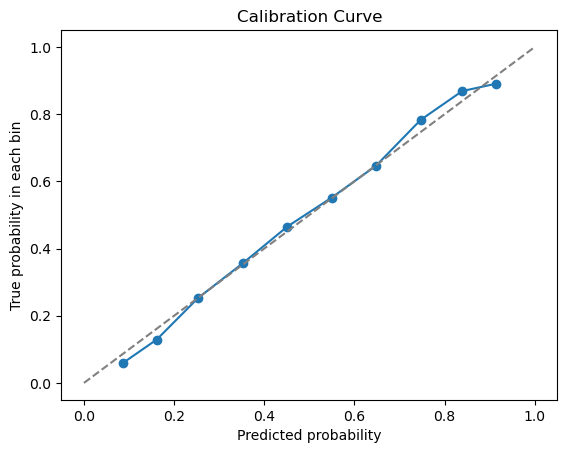

In [18]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probas, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability in each bin')
plt.title('Calibration Curve')
plt.show()


## SHAP Values pour l’interprétabilité

In [19]:
%pip install shap

  Using cached shap-0.47.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (992 kB)
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


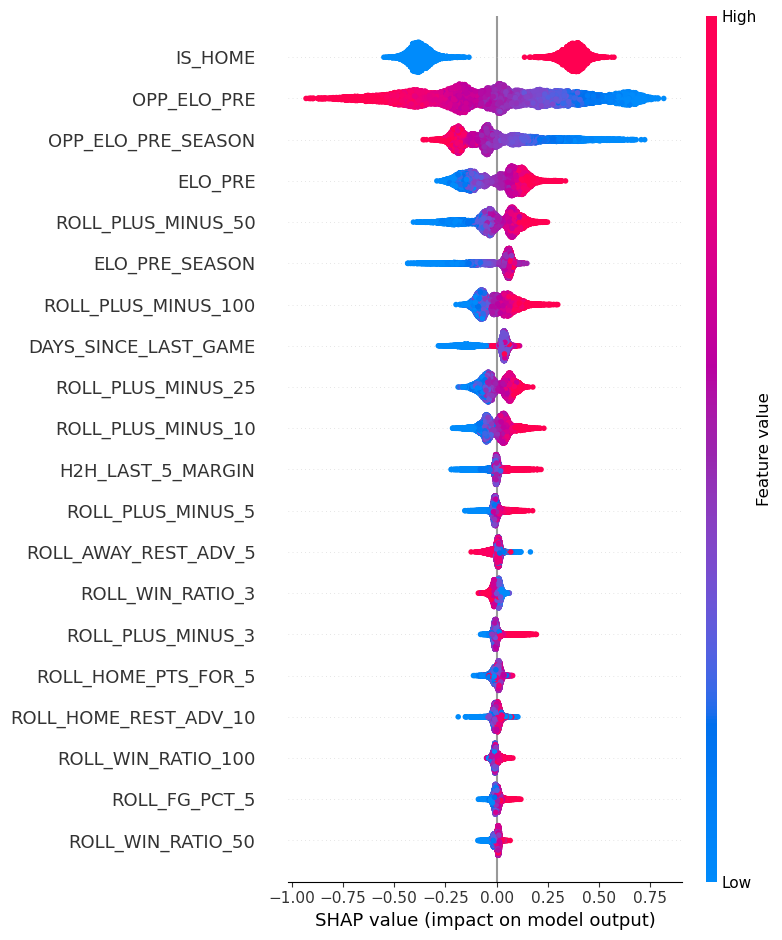

In [20]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


## Permutation importance

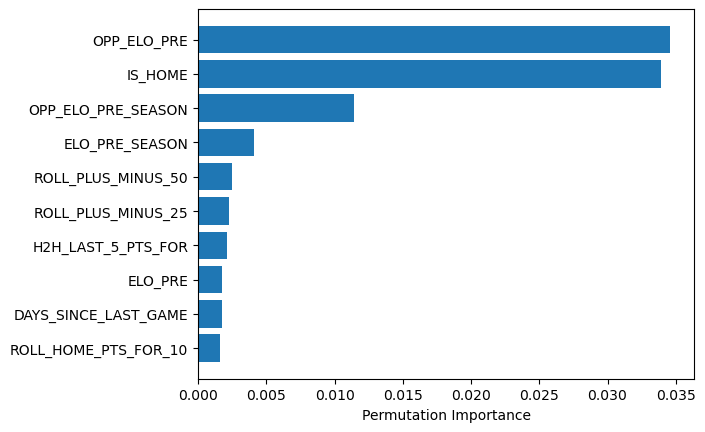

In [21]:
from sklearn.inspection import permutation_importance
result = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[-10:]
plt.barh(np.array(X_test.columns)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.show()


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:41:38] WARNING: /w

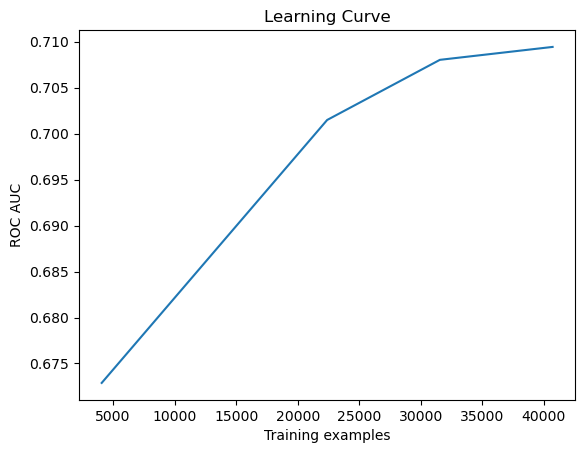

In [22]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(xgb, X, y, cv=3, scoring='roc_auc')
plt.plot(train_sizes, test_scores.mean(axis=1))
plt.title('Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('ROC AUC')
plt.show()


## Stacking des models 

In [23]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Sépare ton X/y normalement (ou récupère ton split habituel)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définis tes modèles de base
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.7, random_state=42, eval_metric='logloss', n_jobs=-1, use_label_encoder=False)),
    ('cat', CatBoostClassifier(n_estimators=200, learning_rate=0.05, depth=6, verbose=0, random_state=42))
]

# Meta-model (peut être LogisticRegression, simple et efficace)
meta_model = LogisticRegression(solver='lbfgs', max_iter=5000)

# Création du stacking
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    passthrough=True,         # (optionnel, passe aussi les features originales au meta-model)
    cv=5,                     # nombre de folds pour stacking, augmente si t'as du temps/RAM
    n_jobs=-1
)

# Fit le stacking
stack.fit(X_train, y_train)

# Prédictions
y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [12:42:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[12:47:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[12:47:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[12:47:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[12:47:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

[12:47:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



[LightGBM] [Info] Number of positive: 19505, number of negative: 19580
[LightGBM] [Info] Number of positive: 19506, number of negative: 19580
[LightGBM] [Info] Number of positive: 19505, number of negative: 19580
[LightGBM] [Info] Number of positive: 19506, number of negative: 19580
[LightGBM] [Info] Number of positive: 19506, number of negative: 19580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31384
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.268264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.319206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enou

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.66      0.67      0.66      6051
           1       0.67      0.66      0.66      6164

    accuracy                           0.66     12215
   macro avg       0.66      0.66      0.66     12215
weighted avg       0.66      0.66      0.66     12215

ROC AUC: 0.7250590669338741


In [24]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-05-23 12:52:47.928832
